Importing Necessary headers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the csv file

In [ ]:
df=pd.read_csv("D:/diabetes.csv")
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

printing basic info anout the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Describing the data set

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


checking for null values in the the data set

In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Printing the shape of data

In [6]:
df.shape

(768, 9)

checking the data types

In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
df.duplicated().sum()

0

checking for outliers and ploting the boxplot

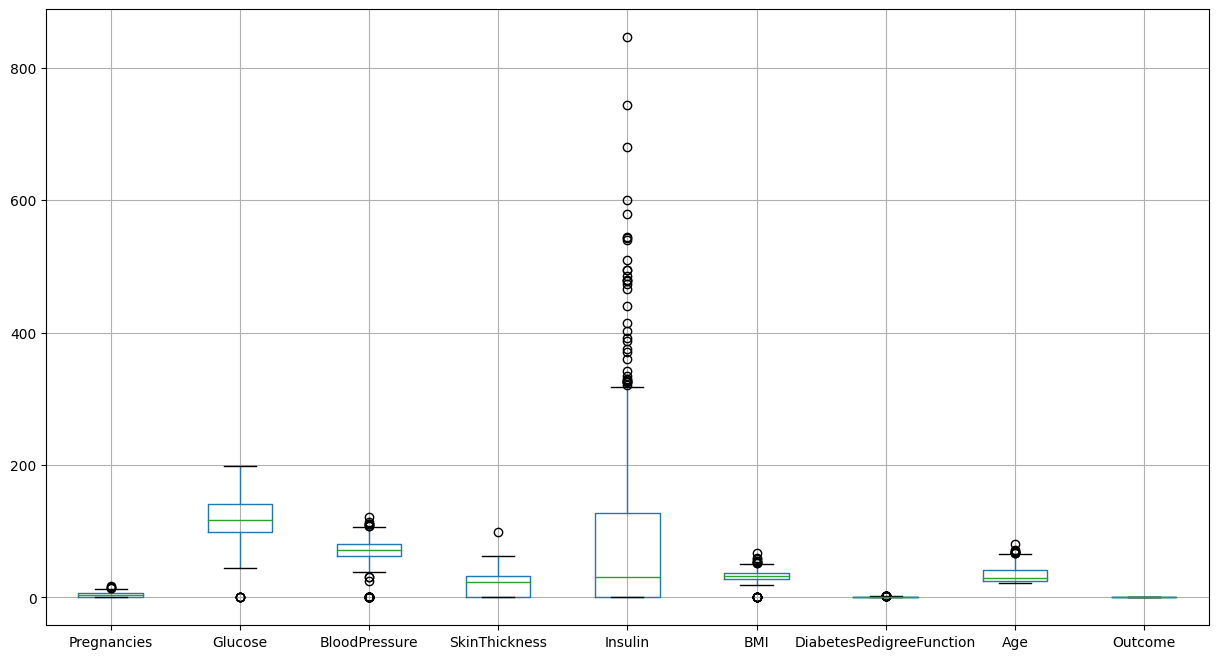

In [9]:
df.boxplot(figsize=(15,8))
plt.show()


In [10]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
print(((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).sum())

Pregnancies                  4
Glucose                      5
BloodPressure               45
SkinThickness                1
Insulin                     34
BMI                         19
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64


Removing outliers

In [11]:
df1=df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)]
print(((df1<(Q1-1.5*IQR))|(df1>(Q3+1.5*IQR))).sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


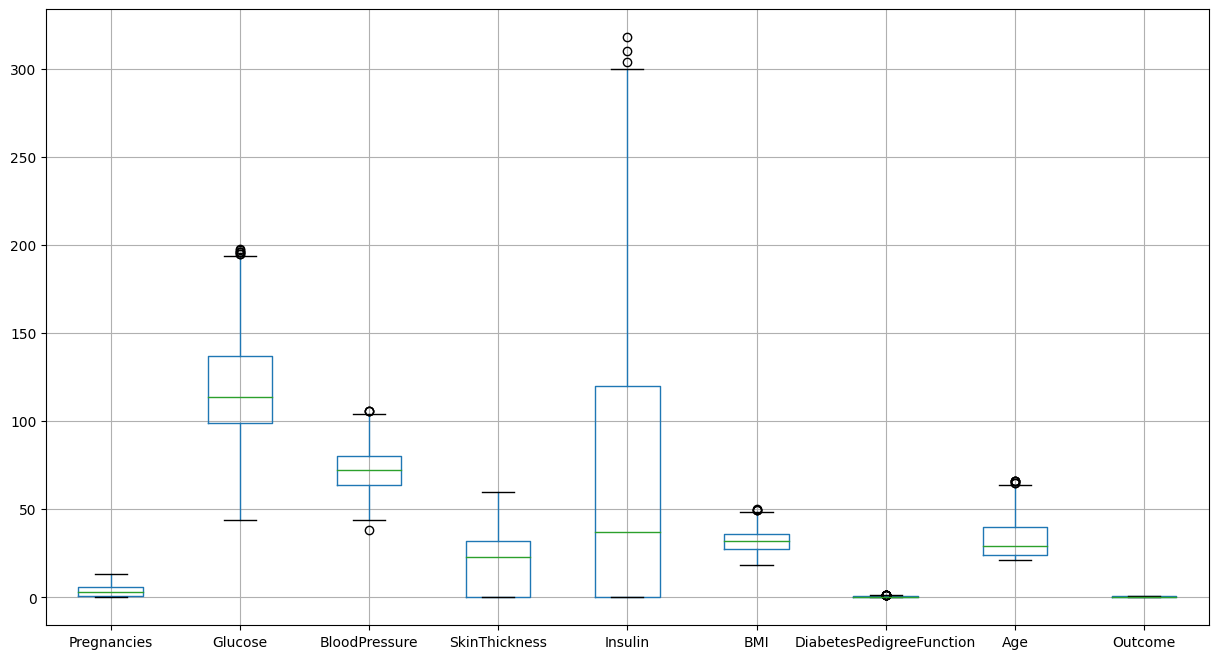

In [12]:
df1.boxplot(figsize=(15,8))
plt.show()

In [13]:
df1.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

ploting histogram

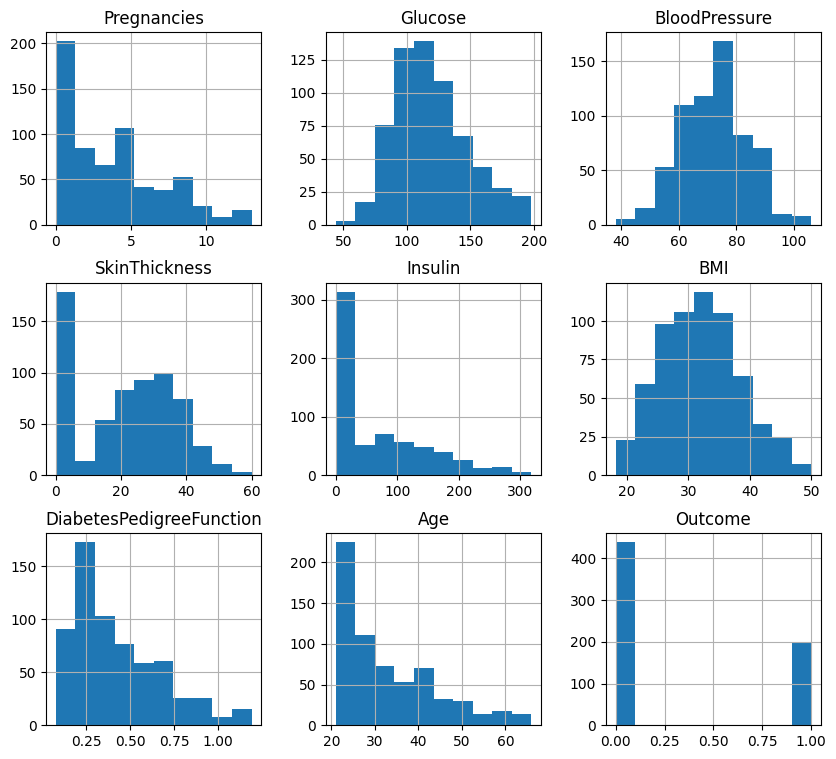

In [14]:
df1.hist(figsize=(10,9))
plt.show()

ploting correlation matrix

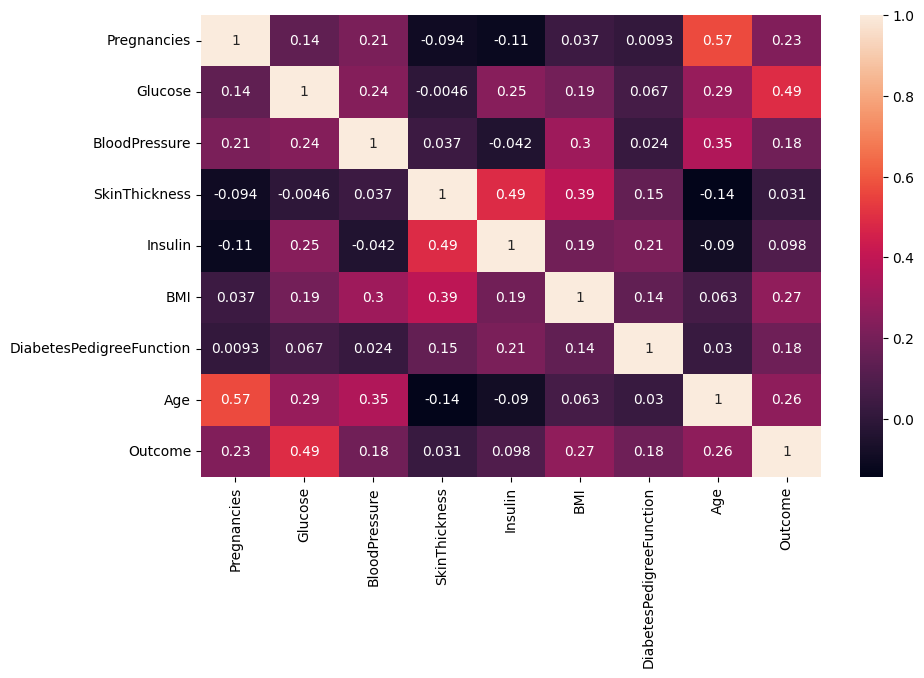

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(),annot=True)
plt.show()

feature selection

In [16]:
x = df1.drop(["Outcome"],axis=1)
y=df1["Outcome"]
print("independent features :" ,x.columns)
print("Dependent features :",y.name)

independent features : Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
Dependent features : Outcome


ploting scatter plots for all independent and dependent features

In [ ]:
for col in x.columns:
  plt.scatter(x[col],y)
  plt.xlabel(col)
  plt.ylabel(y.name)
  plt.show()


Normalizing the data

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(df1)
x_scaled=pd.DataFrame(x_scaled,columns=df1.columns)
print(x_scaled)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.461538  0.675325       0.500000       0.583333  0.000000  0.484277   
1       0.076923  0.266234       0.411765       0.483333  0.000000  0.264151   
2       0.615385  0.902597       0.382353       0.000000  0.000000  0.160377   
3       0.076923  0.292208       0.411765       0.383333  0.295597  0.311321   
4       0.384615  0.467532       0.529412       0.000000  0.000000  0.232704   
..           ...       ...            ...            ...       ...       ...   
634     0.769231  0.370130       0.558824       0.800000  0.566038  0.462264   
635     0.153846  0.506494       0.470588       0.450000  0.000000  0.584906   
636     0.384615  0.500000       0.500000       0.383333  0.352201  0.251572   
637     0.076923  0.532468       0.323529       0.000000  0.000000  0.374214   
638     0.076923  0.318182       0.470588       0.516667  0.000000  0.383648   

     DiabetesPedigreeFunction       Age

In [19]:
x_scaled.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Defining target

In [24]:
target =x_scaled["Outcome"]

Defining training data

In [25]:
# getting train data from the dataframe
train = x_scaled.drop("Outcome",axis=1)

In [54]:
print("independent features :" ,train.columns)
print("Dependent features :",target.name)

independent features : Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
Dependent features : Outcome


Splitting data

In [26]:
# Splitting between train data into training and validation dataset
X_train, X_test, y_train, y_test = train_test_split(
    train, target, test_size=0.20)

# Bagging

In [ ]:
# importing machine learning models for prediction
import xgboost as xgb

In [ ]:
# importing bagging module
from sklearn.ensemble import BaggingClassifier

defining number of  folds

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import model_selection
kfold = model_selection.KFold(n_splits = 3)


initialize the base classifier,no. of base classifier and bagging classifier

In [28]:
# initialize the base classifier
base_cls = DecisionTreeClassifier()
  
# no. of base classifier
num_trees = 200
  
# bagging classifier
model = BaggingClassifier(base_estimator = base_cls,
                          n_estimators = num_trees)

fitting in the model

In [29]:
model.fit(X_train, y_train)


c:\Users\vijay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=200)

predicting 

In [30]:
y_pred = model.predict(X_test)
print(y_pred)

[0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0.
 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 1.]


Evaluation of the Model

In [31]:
# Checking the Accuaracy of the model
acc = model_selection.cross_val_score(model, X_train, y_train, cv = kfold)
print("accuracy :",acc.mean())

c:\Users\vijay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
c:\Users\vijay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
c:\Users\vijay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


accuracy : 0.7729962160302718


In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,f1_score
# Confusion Matrix
confusion_matrix(y_test, y_pred)

array([[77, 10],
       [21, 20]], dtype=int64)

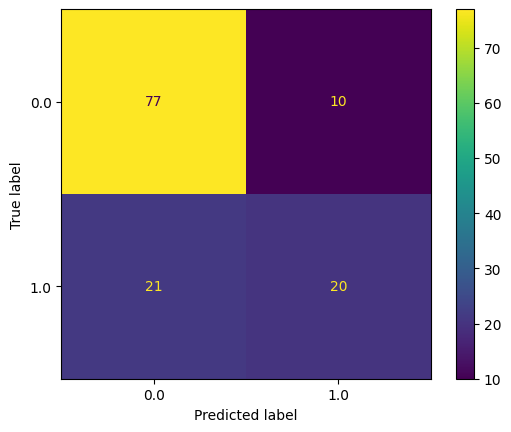

In [33]:
# Plotting the confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

In [34]:
# Generating the Classification Report using Sklearn

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.89      0.83        87
         1.0       0.67      0.49      0.56        41

    accuracy                           0.76       128
   macro avg       0.73      0.69      0.70       128
weighted avg       0.75      0.76      0.75       128



In [35]:
# Calculating F1 score
f1_score(y_test, y_pred, average='macro')

0.6979063570612867

# Boosting

In [36]:
x_scaled.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

developing xgboost model,and predicting

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb = XGBClassifier(booster = 'gblinear', learning_rate = 1, max_depth = 3, n_estimators = 10)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print(y_pred)


[18:31:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "max_depth" } are not used.

[0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1
 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0
 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


Evaluation of the Model

printing accurcy

In [38]:
xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy of XGB Model is {xgb_train_acc}")
print(f"Test Accuracy of XGB Model is {xgb_test_acc}")

Training Accuracy of XGB Model is 0.7416829745596869
Test Accuracy of XGB Model is 0.703125


In [39]:
# confusion matrix

confusion_matrix(y_test, y_pred)

array([[73, 14],
       [24, 17]], dtype=int64)

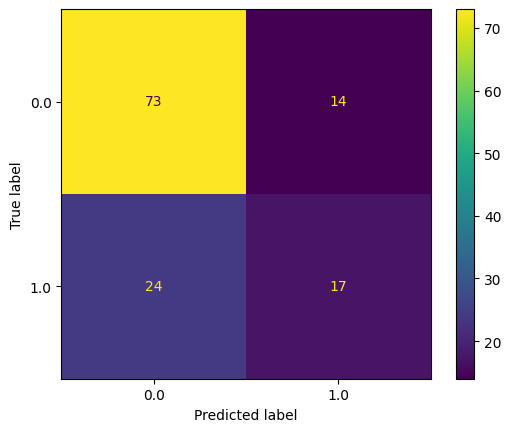

In [40]:
# Plotting the confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

In [41]:
# Generating the Classification Report using Sklearn

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.84      0.79        87
         1.0       0.55      0.41      0.47        41

    accuracy                           0.70       128
   macro avg       0.65      0.63      0.63       128
weighted avg       0.69      0.70      0.69       128



In [42]:
# Calculating F1 score
f1_score(y_test, y_pred, average='macro')

0.6328502415458936

# Stacking

defining base models

In [43]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Initialize the base models
svm = SVC(kernel="linear", C=1)
logistic = LogisticRegression(solver="liblinear")
rf = RandomForestClassifier(n_estimators=100)

Fit the base models

In [55]:
# Fit the base models to the train set
svm.fit(X_train, y_train)
logistic.fit(X_train, y_train)
rf.fit(X_train, y_train)


RandomForestClassifier()

Get the predictions

In [45]:
# Get the predictions of the base models on the test set
svm_pred = svm.predict(X_test)
logistic_pred = logistic.predict(X_test)
rf_pred = rf.predict(X_test)

Create a meta model and fitting

In [46]:
# Create a meta model
meta = LogisticRegression()

In [47]:
# Fit the meta model to the predictions of the base models
meta.fit(np.column_stack([svm_pred, logistic_pred, rf_pred]), y_test)

LogisticRegression()

printing predictions

In [48]:
# Get the predictions of the meta model on the test set
meta_pred = meta.predict(np.column_stack([svm_pred, logistic_pred, rf_pred]))
print(meta_pred)

[0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0.]


Evaluation of the Model

In [49]:
# Calculate the accuracy, confusion matrix of the meta model
accuracy = accuracy_score(y_test, meta_pred)
print("Accuracy:", accuracy)
confusion_matrix(y_test, meta_pred)


Accuracy: 0.78125


array([[81,  6],
       [22, 19]], dtype=int64)

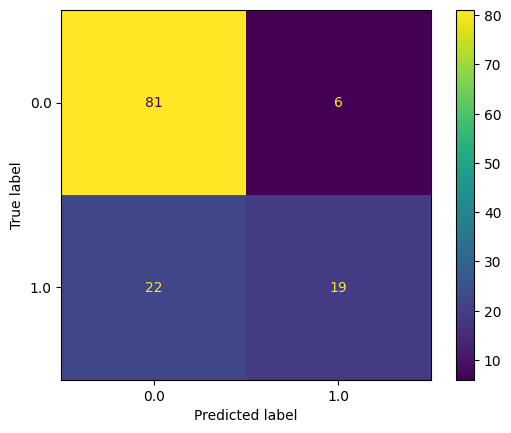

In [50]:
# Plotting the confusion Matrix
cm = confusion_matrix(y_test, meta_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

In [56]:
# Generating the Classification Report using Sklearn

print(classification_report(y_test, meta_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85        87
         1.0       0.76      0.46      0.58        41

    accuracy                           0.78       128
   macro avg       0.77      0.70      0.71       128
weighted avg       0.78      0.78      0.76       128



In [51]:
#  f1 score
f1 = f1_score(y_test, meta_pred)
print("F1 score:", f1)

F1 score: 0.5757575757575758
